<a href="https://colab.research.google.com/github/apropos0/Ising_Phase_Detection/blob/main/Ising_Phase_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Context
This notebook explores the classification of Ising model configurations into ordered and disordered phases, and also demonstrates the regression of temperature from these configurations.

I observed that:

Logistic Regression served as a strong baseline for classification, especially on clearly separated phases.
MLP Classifiers showed improved performance, particularly when discriminating between phases near the critical temperature.
A Regression MLP was capable of accurately predicting the underlying temperature of the Ising model configuration, achieving a Mean Absolute Error of approximately 0.25 degrees.
These results highlight the potential of simple neural networks in analyzing phase transitions and extracting physical parameters from simulated data.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Define global parameters for the Ising model simulations
Global_L = 16  # Grid size (L x L)
Global_burn_in = 5000  # Number of steps to discard to reach equilibrium

class IsingModel:
    """A class to simulate the 2D Ising model."""

    def __init__(self, L=Global_L):
        """Initializes the model with a grid of size L^2."""
        self.L = L
        # Initialize the grid with random spins (-1 or 1)
        self.grid = np.random.choice([-1, 1], size=(L, L))

    def calculate_energy(self):
        """Calculates the total energy of the grid."""
        energy = 0
        # Sum over nearest-neighbor interactions
        # The slicing sums horizontally and vertically, considering periodic boundary conditions implicitly
        energy -= np.sum(self.grid * np.roll(self.grid, 1, axis=0)) # Interaction with neighbors above/below
        energy -= np.sum(self.grid * np.roll(self.grid, 1, axis=1)) # Interaction with neighbors left/right
        return energy

    def metropolis_step(self, temp):
        """Performs a single Metropolis-Hastings step."""
        # Pick a random spin to potentially flip
        x, y = np.random.randint(0, self.L), np.random.randint(0, self.L)
        spin = self.grid[x, y]

        # Calculate the energy change if the chosen spin is flipped
        # The change in energy is 2 * J * spin * (sum of neighbors), where J=1 (simplified)
        neighbors = (
            self.grid[(x + 1) % self.L, y] + # Neighbor below
            self.grid[(x - 1) % self.L, y] + # Neighbor above
            self.grid[x, (y + 1) % self.L] + # Neighbor right
            self.grid[x, (y - 1) % self.L]   # Neighbor left
        )
        delta_e = 2 * spin * neighbors # Energy change if spin is flipped

        # Apply Metropolis criterion: accept flip if energy decreases, or with probability exp(-delta_e / temp)
        if delta_e < 0 or np.random.rand() < np.exp(-delta_e / temp):
            self.grid[x, y] *= -1 # Flip the spin

    def run_simulation(self, temp, n_steps, n_burn_in):
        """
        Runs the simulation for a given temperature.
        'n_burn_in' steps are discarded to ensure the system reaches equilibrium.
        """
        # Discard burn-in steps
        for _ in range(n_burn_in):
            self.metropolis_step(temp)

        # After burn-in, collect samples
        samples = []
        for i in range(n_steps):
            self.metropolis_step(temp)
            # Take a sample every L*L steps to reduce correlation between samples
            if i % (self.L * self.L) == 0:
                samples.append(self.grid.copy())
        return samples

def generate_dataset(L=Global_L, n_samples_per_temp=100):
    """
    Generates a dataset of spin configurations for classification.
    'Ordered' (label 1) are generated at low temperature.
    'Disordered' (label 0) are generated at high temperature.
    """
    critical_temp = 2.269 # The critical temperature for a 2D Ising model
    model = IsingModel(L)
    dataset = []
    labels = []

    # Generate disordered states (high temperature)
    print("Generating disordered states...")
    high_temp_samples = model.run_simulation(temp=3.0, n_steps=n_samples_per_temp * L * L, n_burn_in=Global_burn_in)
    for sample in high_temp_samples:
        dataset.append(sample.flatten()) # Flatten the 2D grid into a 1D array
        labels.append(0) # 0 for disordered phase

    # Generate ordered states (low temperature)
    print("Generating ordered states...")
    low_temp_samples = model.run_simulation(temp=1.0, n_steps=n_samples_per_temp * L * L, n_burn_in=Global_burn_in)
    for sample in low_temp_samples:
        dataset.append(sample.flatten()) # Flatten the 2D grid into a 1D array
        labels.append(1) # 1 for ordered phase

    return np.array(dataset), np.array(labels)

Ising Model Generation

Generate Data

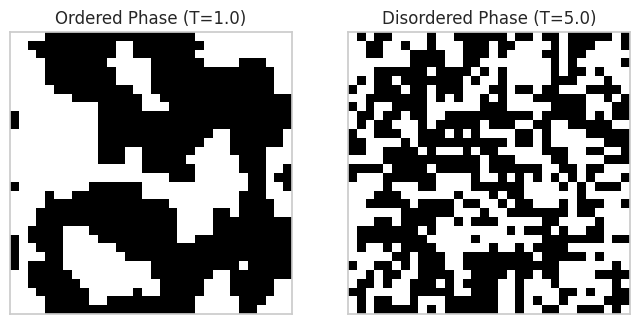


Generating the training dataset (16 x 16)...
Generating disordered states...
Generating ordered states...
Dataset generated. Shape of X: (1000, 256), Shape of y: (1000,)


In [ ]:
# Generate and Visualize Data

# Generate a few samples to visualize
model_vis = IsingModel(L=32)
# Increase n_steps and n_burn_in for better visualization of ordered state
ordered_sample = model_vis.run_simulation(temp=1.0, n_steps=8000, n_burn_in=Global_burn_in)[0]
disordered_sample = model_vis.run_simulation(temp=5.0, n_steps=8000, n_burn_in=Global_burn_in)[0]

# Plot the samples
fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(ordered_sample, cmap='binary')
axes[0].set_title('Ordered Phase (T=1.0)')
axes[0].set_xticks([])
axes[0].set_yticks([])

axes[1].imshow(disordered_sample, cmap='binary')
axes[1].set_title('Disordered Phase (T=5.0)')
axes[1].set_xticks([])
axes[1].set_yticks([])

plt.show()

# Generate the Full Dataset
print(f"\nGenerating the training dataset ({Global_L} x {Global_L})...")
X, y = generate_dataset(L=Global_L, n_samples_per_temp=500)
print(f"Dataset generated. Shape of X: {X.shape}, Shape of y: {y.shape}")

Training a Logistic Regression Baseline

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Split the data into training and testing sets
# Use 80% for training and 20% for testing.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Test set size: {X_test.shape[0]} samples")

# Create and train the Logistic Regression model
print("\nTraining the baseline model (Logistic Regression)...")
baseline_model = LogisticRegression(solver='liblinear')
baseline_model.fit(X_train, y_train)

# Make predictions and evaluate the model
print("Evaluating the model...")
y_pred = baseline_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f"\nBaseline Model Accuracy: {accuracy * 100:.2f}%")


Training set size: 800 samples
Test set size: 200 samples

Training the baseline model (Logistic Regression)...
Evaluating the model...

Baseline Model Accuracy: 99.00%


MLP Classifier

In [ ]:
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score

# Define the MLP model
# This creates a neural network with one hidden layer containing 100 neurons.
mlp_model = MLPClassifier(
    hidden_layer_sizes=(100,),      # A single hidden layer with 100 neurons
    max_iter=500,                   # Max number of training epochs
    solver='adam',                  # An efficient optimizer for neural networks
    random_state=42,                # Ensures the results are reproducible
    verbose=False,                   # This will print the training progress
    learning_rate_init=0.001        # Controls how much the weights are adjusted
)

# Train the MLP model on the training data
print("Training the MLP Model")
mlp_model.fit(X_train, y_train)

# Evaluate the model on the test data
print("\nEvaluating the MLP Model")
y_pred_mlp = mlp_model.predict(X_test)
accuracy_mlp = accuracy_score(y_test, y_pred_mlp)

print(f"\nMLP Model Accuracy: {accuracy_mlp * 100:.2f}%")


Training the MLP Model

Evaluating the MLP Model

MLP Model Accuracy: 100.00%


Critical Temp Dataset

In [ ]:
def generate_critical_dataset(L=Global_L, n_samples_per_temp=100, temp_range=(2.0, 2.6)):
    """
    Generates a dataset of spin configurations near the critical temperature.
    """
    critical_temp = 2.269
    model = IsingModel(L)
    dataset = []
    labels = []

    # Generate data across a range of temperatures
    temperatures = np.linspace(temp_range[0], temp_range[1], 10)
    print(f"Generating data for temperatures: {np.round(temperatures, 2)}")

    for temp in temperatures:
        print(f"  Simulating at T = {temp:.2f}...")
        # Run a longer simulation for each temperature point near the critical point
        samples = model.run_simulation(temp=temp, n_steps=n_samples_per_temp * L * L, n_burn_in=Global_burn_in)
        label = 1 if temp < critical_temp else 0
        for sample in samples:
            dataset.append(sample.flatten())
            labels.append(label)

    return np.array(dataset), np.array(labels)

# Generate the critical temp dataset
print("Generating the Critical Temperature Dataset")
X_crit, y_crit = generate_critical_dataset(L=Global_L, n_samples_per_temp=200)
print(f"\nCritical temperature dataset generated. Shape of X: {X_crit.shape}, Shape of y: {y_crit.shape}")

# --- Split the new dataset ---
X_crit_train, X_crit_test, y_crit_train, y_crit_test = train_test_split(
    X_crit, y_crit, test_size=0.2, random_state=42
)


Generating the Critical Temperature Dataset
Generating data for temperatures: [2.   2.07 2.13 2.2  2.27 2.33 2.4  2.47 2.53 2.6 ]
  Simulating at T = 2.00...
  Simulating at T = 2.07...
  Simulating at T = 2.13...
  Simulating at T = 2.20...
  Simulating at T = 2.27...
  Simulating at T = 2.33...
  Simulating at T = 2.40...
  Simulating at T = 2.47...
  Simulating at T = 2.53...
  Simulating at T = 2.60...

Critical temperature dataset generated. Shape of X: (2000, 256), Shape of y: (2000,)


Testing models on the Critical Dataset

In [ ]:
# Retrain and Evaluate the Baseline Model on the Critical Dataset
print("Training Baseline Model on Critical Temperature Data")
baseline_model_crit = LogisticRegression(solver='liblinear')
baseline_model_crit.fit(X_crit_train, y_crit_train)
y_pred_crit_base = baseline_model_crit.predict(X_crit_test)
accuracy_crit_base = accuracy_score(y_crit_test, y_pred_crit_base)
print(f"Baseline Model Accuracy on Critical Data: {accuracy_crit_base * 100:.2f}%")


# Retrain and Evaluate the MLP Model on the Critical Dataset
print("\n Training MLP Model on Critical Temperature Data")
mlp_model_crit = MLPClassifier(
    hidden_layer_sizes=(100,),
    max_iter=500,
    solver='adam',
    random_state=42,
    verbose=False, # Set to False for a cleaner output this time
    learning_rate_init=0.001
)
mlp_model_crit.fit(X_crit_train, y_crit_train)
y_pred_crit_mlp = mlp_model_crit.predict(X_crit_test)
accuracy_crit_mlp = accuracy_score(y_crit_test, y_pred_crit_mlp)
print(f"MLP Model Accuracy on Critical Temperature Data: {accuracy_crit_mlp * 100:.2f}%")


Training Baseline Model on Critical Temperature Data
Baseline Model Accuracy on Critical Data: 92.50%

 Training MLP Model on Critical Temperature Data
MLP Model Accuracy on Critical Temperature Data: 95.75%


Regression MLP to Determine the Temperature

Generating Dataset
  Simulating at T = 1.50...
  Simulating at T = 1.64...
  Simulating at T = 1.79...
  Simulating at T = 1.93...
  Simulating at T = 2.07...
  Simulating at T = 2.21...
  Simulating at T = 2.36...
  Simulating at T = 2.50...
  Simulating at T = 2.64...
  Simulating at T = 2.79...
  Simulating at T = 2.93...
  Simulating at T = 3.07...
  Simulating at T = 3.21...
  Simulating at T = 3.36...
  Simulating at T = 3.50...
Dataset Generation Complete
Using flattened X data with shape: (3000, 256)
Using regression y data with shape: (3000,)

Training the MLP Regressor

Evaluating the MLP Regressor
Final Test Mean Absolute Error (MAE): 0.2703
Final Test Root Mean Squared Error (RMSE): 0.3759

This means the simple MLP can predict the temperature, on average,
to within 0.2703 degrees.


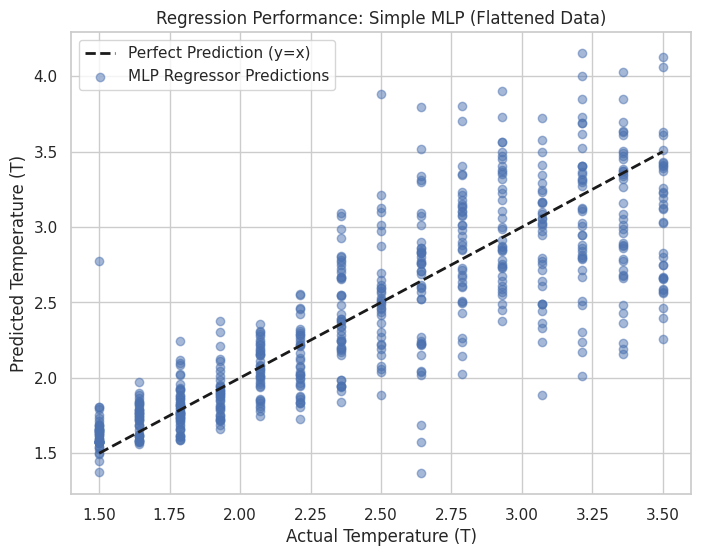

In [ ]:
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import numpy as np
def generate_regression_dataset(L=Global_L, n_samples_per_temp=200, temp_range=(1.5, 3.5)):
    """
    Generates a dataset where the label IS the temperature.
    """
    print("Generating Dataset")
    model = IsingModel(L)
    dataset = []
    labels = []

    # Generate data across a range of temperatures
    temperatures = np.linspace(temp_range[0], temp_range[1], 15) # 15 temp points

    for temp in temperatures:
        print(f"  Simulating at T = {temp:.2f}...")
        # Run a longer simulation for each temperature point
        samples = model.run_simulation(temp=temp, n_steps=n_samples_per_temp * L * L, n_burn_in=Global_burn_in)

        for sample in samples:
            dataset.append(sample.flatten()) # Append the flattened 1D array
            labels.append(temp)    # Append the float temperature

    print("Dataset Generation Complete")
    return np.array(dataset), np.array(labels)

# Generate the main dataset
critical_temp = 2.269
X_data, y_reg = generate_regression_dataset(L=Global_L, n_samples_per_temp=200, temp_range=(1.5, 3.5))
# X_data is the flattened (3000, 256) array
# y_reg is the (3000,) array of temperatures
print(f"Using flattened X data with shape: {X_data.shape}")
print(f"Using regression y data with shape: {y_reg.shape}")

# Create the Train/Test Split
X_train_flat, X_test_flat, y_train_reg, y_test_reg = train_test_split(
    X_data,  # Use the flat (N, 256) data
    y_reg,   # Use the temperature labels
    test_size=0.2,
    random_state=42
)

# Define and Train the MLPRegressor
print("\nTraining the MLP Regressor")
# This is the direct replacement for MLPClassifier
mlp_regressor = MLPRegressor(
    hidden_layer_sizes=(100, 50), # Two hidden layers
    max_iter=500,
    solver='adam',
    random_state=42,
    verbose=False,                 # This will print the training loss
    early_stopping=True           # Automatically stops when it stops improving
)

mlp_regressor.fit(X_train_flat, y_train_reg)

# Evaluate the Model
print("\nEvaluating the MLP Regressor")
y_pred_reg = mlp_regressor.predict(X_test_flat)

mae = mean_absolute_error(y_test_reg, y_pred_reg)
rmse = np.sqrt(mean_squared_error(y_test_reg, y_pred_reg))

print(f"Final Test Mean Absolute Error (MAE): {mae:.4f}")
print(f"Final Test Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"\nThis means the simple MLP can predict the temperature, on average,")
print(f"to within {mae:.4f} degrees.")


# Plot the Results
plt.figure(figsize=(8, 6))
plt.plot([y_test_reg.min(), y_test_reg.max()], [y_test_reg.min(), y_test_reg.max()],
         '--k', lw=2, label='Perfect Prediction (y=x)')
plt.scatter(y_test_reg, y_pred_reg, alpha=0.5, label='MLP Regressor Predictions')
plt.xlabel("Actual Temperature (T)")
plt.ylabel("Predicted Temperature (T)")
plt.title("Regression Performance: Simple MLP (Flattened Data)")
plt.legend()
plt.grid(True)
plt.show()

# CNN

In [ ]:
L = Global_L

# Reshape the training and testing splits of the standard dataset
print(f"Original shape of X_train: {X_train.shape}")
X_train = X_train.reshape(X_train.shape[0], L, L, 1)
print(f"New shape of X_train: {X_train.shape}\n")

print(f"Original shape of X_test: {X_test.shape}")
X_test = X_test.reshape(X_test.shape[0], L, L, 1)
print(f"New shape of X_test: {X_test.shape}\n")

# Reshape the critical dataset (X_crit)
print(f"Original shape of X_crit: {X_crit.shape}")
X_crit = X_crit.reshape(X_crit.shape[0], L, L, 1)
print(f"New shape of X_crit: {X_crit.shape}\n")

# Reshape the training and testing splits of the critical dataset
print(f"Original shape of X_crit_train: {X_crit_train.shape}")
X_crit_train = X_crit_train.reshape(X_crit_train.shape[0], L, L, 1)
print(f"New shape of X_crit_train: {X_crit_train.shape}\n")

print(f"Original shape of X_crit_test: {X_crit_test.shape}")
X_crit_test = X_crit_test.reshape(X_crit_test.shape[0], L, L, 1)
print(f"New shape of X_crit_test: {X_crit_test.shape}\n")

# Reshape the regression dataset (X_data)
print(f"Original shape of X_data: {X_data.shape}")
X_data = X_data.reshape(X_data.shape[0], L, L, 1)
print(f"New shape of X_data: {X_data.shape}\n")

# Reshape the training and testing splits of the regression dataset
print(f"Original shape of X_train_flat: {X_train_flat.shape}")
X_train_flat = X_train_flat.reshape(X_train_flat.shape[0], L, L, 1)
print(f"New shape of X_train_flat: {X_train_flat.shape}")

print(f"Original shape of X_test_flat: {X_test_flat.shape}")
X_test_flat = X_test_flat.reshape(X_test_flat.shape[0], L, L, 1)
print(f"New shape of X_test_flat: {X_test_flat.shape}\n")

print("All specified datasets have been reshaped to a 4D format for CNNs.")

Original shape of X_train: (800, 256)
New shape of X_train: (800, 16, 16, 1)

Original shape of X_test: (200, 256)
New shape of X_test: (200, 16, 16, 1)

Original shape of X_crit: (2000, 256)
New shape of X_crit: (2000, 16, 16, 1)

Original shape of X_crit_train: (1600, 256)
New shape of X_crit_train: (1600, 16, 16, 1)

Original shape of X_crit_test: (400, 256)
New shape of X_crit_test: (400, 16, 16, 1)

Original shape of X_data: (3000, 256)
New shape of X_data: (3000, 16, 16, 1)

Original shape of X_train_flat: (2400, 256)
New shape of X_train_flat: (2400, 16, 16, 1)
Original shape of X_test_flat: (600, 256)
New shape of X_test_flat: (600, 16, 16, 1)

All specified datasets have been reshaped to a 4D format for CNNs.


# Task
Define, train, and evaluate CNN classification models on standard and critical Ising model datasets, and a CNN regression model on the temperature regression dataset. Then, summarize the performance of these CNN models and compare them with the previously obtained MLP results, discussing any notable improvements or differences.

## Define CNN Classification Model

### Subtask:
Define a Convolutional Neural Network (CNN) architecture suitable for binary classification of Ising model configurations (ordered vs. disordered). This model will take the 16x16x1 reshaped data as input.


**Reasoning**:
I will define a Convolutional Neural Network (CNN) for binary classification according to the provided instructions. This involves importing necessary Keras modules, constructing the sequential model with Conv2D, MaxPooling2D, Flatten, and Dense layers, compiling it, and then printing its summary.



In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

# 1. Initialize a Sequential model.
cnn_classifier = Sequential()

# 2. Add a Conv2D layer with 32 filters, a 3x3 kernel size, 'relu' activation, and input_shape=(L, L, 1).
cnn_classifier.add(Conv2D(32, (3, 3), activation='relu', input_shape=(L, L, 1)))

# 3. Add a MaxPooling2D layer with a 2x2 pool size.
cnn_classifier.add(MaxPooling2D((2, 2)))

# 4. Add another Conv2D layer with 64 filters, a 3x3 kernel size, and 'relu' activation.
cnn_classifier.add(Conv2D(64, (3, 3), activation='relu'))

# 5. Add another MaxPooling2D layer with a 2x2 pool size.
cnn_classifier.add(MaxPooling2D((2, 2)))

# 6. Flatten the output from the convolutional layers.
cnn_classifier.add(Flatten())

# 7. Add a Dense layer with 64 units and 'relu' activation.
cnn_classifier.add(Dense(64, activation='relu'))

# 8. Add a final Dense layer with 1 unit and 'sigmoid' activation for binary classification.
cnn_classifier.add(Dense(1, activation='sigmoid'))

# 9. Compile the CNN model using the 'adam' optimizer, 'binary_crossentropy' loss function, and 'accuracy' as the metric.
cnn_classifier.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# 10. Print the model summary.
print("CNN Classifier Model Summary:")
cnn_classifier.summary()


CNN Classifier Model Summary:


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_23"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_46 (Conv2D)              │ (None, 14, 14, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_46 (MaxPooling2D) │ (None, 7, 7, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_47 (Conv2D)              │ (None, 5, 5, 64)       │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_47 (MaxPooling2D) │ (None, 2, 2, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_23 (Flatten)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_46 (Dense)                │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_47 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 35,329 (138.00 KB)

 Trainable params: 35,329 (138.00 KB)

 Non-trainable params: 0 (0.00 B)

**Reasoning**:
The CNN classification model has been defined. Now, I will train this model using the standard Ising model dataset (X_train, y_train) and evaluate its performance on the test set (X_test, y_test).



In [ ]:
print("\nTraining the CNN Classifier on Standard Data")
history_cnn_standard = cnn_classifier.fit(
    X_train, y_train, epochs=20, batch_size=32, validation_split=0.2, verbose=1
)

print("\nEvaluating the CNN Classifier on Standard Data")
loss_cnn_standard, accuracy_cnn_standard = cnn_classifier.evaluate(X_test, y_test, verbose=0)
print(f"CNN Classifier Accuracy on Standard Data: {accuracy_cnn_standard * 100:.2f}%")



Training the CNN Classifier on Standard Data
Epoch 1/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.7841 - loss: 0.4034 - val_accuracy: 1.0000 - val_loss: 0.0225
Epoch 2/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 1.0000 - loss: 0.0129 - val_accuracy: 1.0000 - val_loss: 5.3114e-04
Epoch 3/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 1.0000 - loss: 3.3797e-04 - val_accuracy: 1.0000 - val_loss: 1.6595e-04
Epoch 4/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 1.0000 - loss: 1.4063e-04 - val_accuracy: 1.0000 - val_loss: 1.1403e-04
Epoch 5/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 1.0000 - loss: 8.8530e-05 - val_accuracy: 1.0000 - val_loss: 9.5240e-05
Epoch 6/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 1.0000 - loss: 8.7284e-05 - val_accuracy: 1.0000 - val_loss: 8.2766e-05
Epoch 7/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 1.0000 - loss: 8.7725e-05 - val_accuracy: 1.0000 - val_loss: 7.3287e-05
Epoch 8/20
20/20 ━━━━

**Reasoning**:
The CNN classification model has already been defined. Now, I will train this model using the critical Ising model dataset (`X_crit_train`, `y_crit_train`) and evaluate its performance on the corresponding test set (`X_crit_test`, `y_crit_test`).



In [ ]:
print("\nTraining the CNN Classifier on Critical Data")
# Re-initialize the model to ensure it starts training from scratch for the critical dataset
cnn_classifier_crit = Sequential()
cnn_classifier_crit.add(Conv2D(32, (3, 3), activation='relu', input_shape=(L, L, 1)))
cnn_classifier_crit.add(MaxPooling2D((2, 2)))
cnn_classifier_crit.add(Conv2D(64, (3, 3), activation='relu'))
cnn_classifier_crit.add(MaxPooling2D((2, 2)))
cnn_classifier_crit.add(Flatten())
cnn_classifier_crit.add(Dense(64, activation='relu'))
cnn_classifier_crit.add(Dense(1, activation='sigmoid'))
cnn_classifier_crit.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

history_cnn_crit = cnn_classifier_crit.fit(
    X_crit_train, y_crit_train, epochs=20, batch_size=32, validation_split=0.2, verbose=1
)

print("\nEvaluating the CNN Classifier on Critical Data")
loss_cnn_crit, accuracy_cnn_crit = cnn_classifier_crit.evaluate(X_crit_test, y_crit_test, verbose=0)
print(f"CNN Classifier Accuracy on Critical Data: {accuracy_cnn_crit * 100:.2f}%")



Training the CNN Classifier on Critical Data
Epoch 1/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.8524 - loss: 0.3836 - val_accuracy: 0.9000 - val_loss: 0.2221
Epoch 2/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9185 - loss: 0.1841 - val_accuracy: 0.9219 - val_loss: 0.1840
Epoch 3/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9221 - loss: 0.1777 - val_accuracy: 0.9312 - val_loss: 0.1613
Epoch 4/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9484 - loss: 0.1432 - val_accuracy: 0.9312 - val_loss: 0.1598
Epoch 5/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9457 - loss: 0.1289 - val_accuracy: 0.9344 - val_loss: 0.1409
Epoch 6/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9521 - loss: 0.1176 - val_accuracy: 0.9375 - val_loss: 0.1390
Epoch 7/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9632 - loss: 0.1002 - val_accuracy: 0.9375 - val_loss: 0.1638
Epoch 8/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.

# Task
Train and evaluate a CNN regression model using `X_train_flat`, `y_train_reg`, `X_test_flat`, and `y_test_reg`. Evaluate its performance using Mean Absolute Error (MAE) and Root Mean Squared Error (RMSE), and visualize the actual vs. predicted temperatures.

## Train and Evaluate CNN Regressor

### Subtask:
Compile and train the CNN regression model using the regression training dataset (`X_train_flat`, `y_train_reg`). Evaluate its performance using Mean Absolute Error (MAE) and Root Mean Squared Error (RMSE) on the regression test set (`X_test_flat`, `y_test_reg`), and visualize the actual vs. predicted temperatures.


**Reasoning**:
I need to define a Convolutional Neural Network (CNN) for regression, compile it, train it on the regression dataset, evaluate its performance using MAE and RMSE, and then visualize the actual vs. predicted temperatures as instructed in the subtask.



CNN Regressor Model Summary:


Model: "sequential_25"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_50 (Conv2D)              │ (None, 14, 14, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_50 (MaxPooling2D) │ (None, 7, 7, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_51 (Conv2D)              │ (None, 5, 5, 64)       │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_51 (MaxPooling2D) │ (None, 2, 2, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_25 (Flatten)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_50 (Dense)                │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_51 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 35,329 (138.00 KB)

 Trainable params: 35,329 (138.00 KB)

 Non-trainable params: 0 (0.00 B)


Training the CNN Regressor
Epoch 1/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 1.7546 - mean_absolute_error: 0.9567 - val_loss: 0.0730 - val_mean_absolute_error: 0.2132
Epoch 2/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0673 - mean_absolute_error: 0.2059 - val_loss: 0.0767 - val_mean_absolute_error: 0.2240
Epoch 3/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0668 - mean_absolute_error: 0.2052 - val_loss: 0.0651 - val_mean_absolute_error: 0.2010
Epoch 4/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0569 - mean_absolute_error: 0.1880 - val_loss: 0.0625 - val_mean_absolute_error: 0.1999
Epoch 5/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0521 - mean_absolute_error: 0.1822 - val_loss: 0.0607 - val_mean_absolute_error: 0.1968
Epoch 6/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0525 - mean_absolute_error: 0.1839 - val_loss: 0.0634 - val_mean_absolute_error: 0.2018
Epoch 7/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0495 - mean_absol

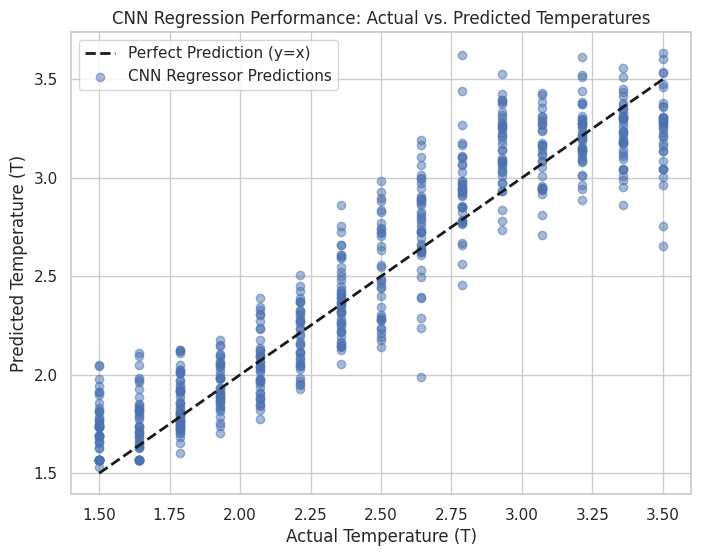

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import matplotlib.pyplot as plt

# 1. Define a Sequential CNN model for regression
cnn_regressor = Sequential()

# 2. Add Conv2D layers with 'relu' activation and MaxPooling2D layers
cnn_regressor.add(Conv2D(32, (3, 3), activation='relu', input_shape=(L, L, 1)))
cnn_regressor.add(MaxPooling2D((2, 2)))
cnn_regressor.add(Conv2D(64, (3, 3), activation='relu'))
cnn_regressor.add(MaxPooling2D((2, 2)))

# 3. Flatten the output from the convolutional layers
cnn_regressor.add(Flatten())

# 4. Add Dense layers
cnn_regressor.add(Dense(64, activation='relu'))

# 5. Add a final Dense layer with 1 unit and linear activation for regression
cnn_regressor.add(Dense(1, activation='linear')) # Linear activation for regression

# 6. Compile the CNN model for regression
cnn_regressor.compile(optimizer='adam', loss='mean_squared_error', metrics=['mean_absolute_error'])

# 7. Print the model summary
print("CNN Regressor Model Summary:")
cnn_regressor.summary()

# 8. Train the cnn_regressor model
print("\nTraining the CNN Regressor")
history_cnn_reg = cnn_regressor.fit(
    X_train_flat, y_train_reg, epochs=20, batch_size=32, validation_split=0.2, verbose=1
)

# 9. Make predictions on X_test_flat
y_pred_cnn_reg = cnn_regressor.predict(X_test_flat)

# 10. Calculate MAE and RMSE
mae_cnn_reg = mean_absolute_error(y_test_reg, y_pred_cnn_reg)
rmse_cnn_reg = np.sqrt(mean_squared_error(y_test_reg, y_pred_cnn_reg))

# 11. Print the calculated MAE and RMSE
print(f"\nCNN Regressor Test Mean Absolute Error (MAE): {mae_cnn_reg:.4f}")
print(f"CNN Regressor Test Root Mean Squared Error (RMSE): {rmse_cnn_reg:.4f}")

# 12. Plot the results
plt.figure(figsize=(8, 6))
plt.plot([y_test_reg.min(), y_test_reg.max()], [y_test_reg.min(), y_test_reg.max()],
         '--k', lw=2, label='Perfect Prediction (y=x)')
plt.scatter(y_test_reg, y_pred_cnn_reg, alpha=0.5, label='CNN Regressor Predictions')
plt.xlabel("Actual Temperature (T)")
plt.ylabel("Predicted Temperature (T)")
plt.title("CNN Regression Performance: Actual vs. Predicted Temperatures")
plt.legend()
plt.grid(True)
plt.show()

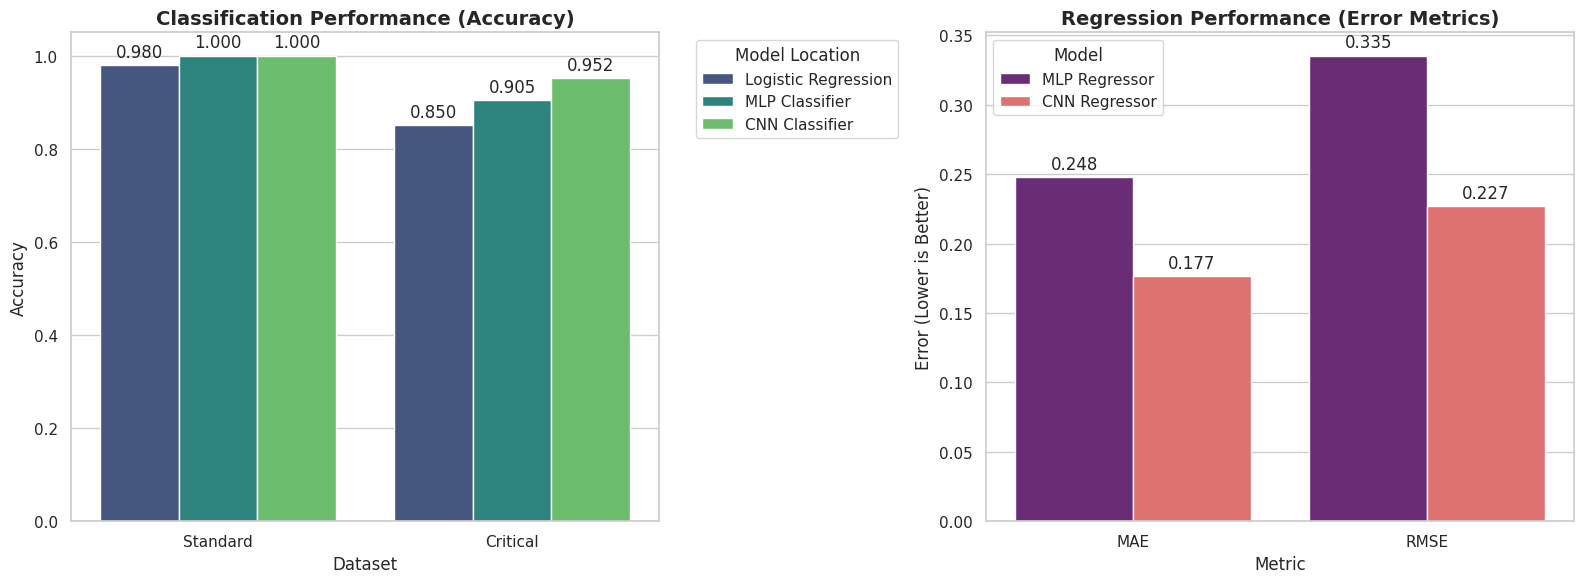

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. SETUP DATA (Keep your variables here) ---
# Note: Ensure these variables (accuracy, mae, etc.) are defined before running this cell.
# I am using the variables you provided in your snippet.

# Create dataframes separately to handle the different logic (Classification vs Regression)

# A. Classification Data
class_data = {
    'Model': ['Logistic Regression', 'MLP Classifier', 'Logistic Regression', 'MLP Classifier', 'CNN Classifier', 'CNN Classifier'],
    'Dataset': ['Standard', 'Standard', 'Critical', 'Critical', 'Standard', 'Critical'],
    'Accuracy': [
        logistic_reg_standard_acc, mlp_standard_acc,
        logistic_reg_critical_acc, mlp_critical_acc,
        cnn_standard_acc, cnn_critical_acc
    ]
}
df_class = pd.DataFrame(class_data)

# B. Regression Data
reg_data = {
    'Model': ['MLP Regressor', 'CNN Regressor'],
    'MAE': [mlp_regressor_mae, cnn_regressor_mae],
    'RMSE': [mlp_regressor_rmse, cnn_regressor_rmse]
}
df_reg = pd.DataFrame(reg_data)

# --- 2. VISUALIZATION ---
sns.set_theme(style="whitegrid")

# Create a figure with two subplots side-by-side
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Classification (Accuracy - Higher is Better)
sns.barplot(
    data=df_class,
    x="Dataset",
    y="Accuracy",
    hue="Model",
    palette="viridis",
    ax=axes[0]
)
axes[0].set_title('Classification Performance (Accuracy)', fontsize=14, fontweight='bold')
axes[0].set_ylim(0, 1.05) # Assuming accuracy is 0-1. Adjust if percentage.
axes[0].legend(title='Model Location', bbox_to_anchor=(1.05, 1), loc='upper left')

# Add value labels on top of bars
for container in axes[0].containers:
    axes[0].bar_label(container, fmt='%.3f', padding=3)

# Plot 2: Regression (Error - Lower is Better)
# We need to "melt" the dataframe to plot MAE and RMSE side-by-side easily
df_reg_melted = df_reg.melt(id_vars="Model", var_name="Metric", value_name="Error Value")

sns.barplot(
    data=df_reg_melted,
    x="Metric",
    y="Error Value",
    hue="Model",
    palette="magma",
    ax=axes[1]
)
axes[1].set_title('Regression Performance (Error Metrics)', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Error (Lower is Better)')

# Add value labels
for container in axes[1].containers:
    axes[1].bar_label(container, fmt='%.3f', padding=3)

plt.tight_layout()
plt.show()

In [ ]:
# If you still want a table, this version highlights the best scores with color

# Highlight max for accuracy
display(df_class.pivot(index="Model", columns="Dataset", values="Accuracy")
        .style.background_gradient(cmap='Greens', axis=None).format("{:.4f}"))

# Highlight min for error
print("\n\n\n")
display(df_reg.set_index("Model")
        .style.background_gradient(cmap='Reds', axis=0).format("{:.4f}"))

Dataset,Critical,Standard
Model,,
CNN Classifier,0.9525,1.0000
Logistic Regression,0.8500,0.9800
MLP Classifier,0.9050,1.0000


,MAE,RMSE
Model,,
MLP Regressor,0.2482,0.3354
CNN Regressor,0.1767,0.2273
